In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [4]:
df = pd.read_csv('auto-insurance.csv', names = [
    'n_claims',
    'total_payment'
])
df

,n_claims,total_payment
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4
...,...,...
58,9,87.4
59,31,209.8
60,14,95.5
61,53,244.6


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   n_claims       63 non-null     int64  
 1   total_payment  63 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [7]:
df.describe()

,n_claims,total_payment
count,63.000000,63.000000
mean,22.904762,98.187302
std,23.351946,87.327553
min,0.000000,0.000000
25%,7.500000,38.850000
50%,14.000000,73.400000
75%,29.000000,140.000000
max,124.000000,422.200000


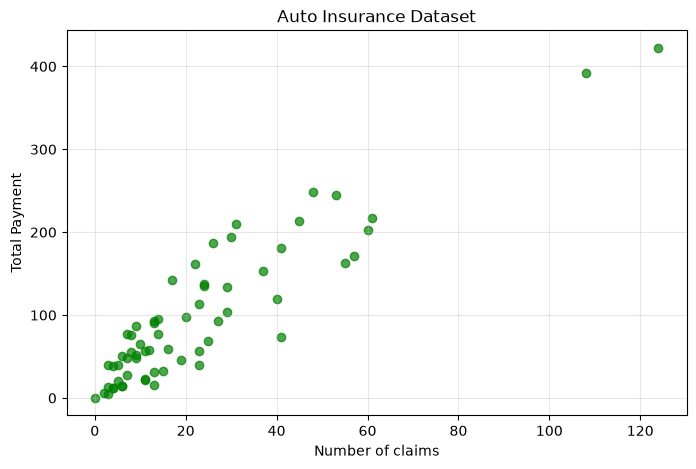

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["n_claims"],
    df["total_payment"],
    color="green",
    alpha=0.7
)

plt.xlabel("Number of claims")
plt.ylabel("Total Payment")
plt.title("Auto Insurance Dataset")

plt.grid(True, alpha=0.3)
plt.show()

In [10]:
normalizer = StandardScaler()
df_normalized = normalizer.fit_transform(df)
df_normalized

array([[ 3.67330185e+00,  3.39728625e+00],
       [-1.68556660e-01, -6.00095564e-01],
       [-4.27558357e-01, -9.52160668e-01],
       [ 4.36397304e+00,  3.74011686e+00],
       [ 7.37949280e-01,  2.44860684e-01],
       [ 1.47178742e+00,  8.39331269e-01],
       [ 4.11113805e-03, -4.76584200e-01],
       [-3.84391408e-01, -2.38795966e-01],
       [ 9.53784027e-01,  1.33683966e+00],
       [-5.57059206e-01, -3.79622008e-01],
       [-7.72893953e-01, -8.92136453e-01],
       [ 1.08328488e+00,  1.73045999e+00],
       [-5.13892256e-01, -8.62124346e-01],
       [ 4.11113805e-03, -6.76280144e-01],
       [-6.86560054e-01, -5.70083457e-01],
       [-9.02394802e-01, -1.05720304e+00],
       [ 4.72780876e-02,  4.23779015e-01],
       [-7.29727004e-01, -5.45842909e-01],
       [-8.59227852e-01, -1.08259790e+00],
       [ 4.11113805e-03,  1.70984728e-01],
       [-7.29727004e-01, -9.62549474e-01],
       [-6.00226155e-01, -5.71237769e-01],
       [-6.00226155e-01, -5.31991167e-01],
       [-8.

In [15]:
X, y = df_normalized[:, 0], df_normalized[:, 1]
X = X.reshape(-1, 1)
print(X)

[[ 3.67330185e+00]
 [-1.68556660e-01]
 [-4.27558357e-01]
 [ 4.36397304e+00]
 [ 7.37949280e-01]
 [ 1.47178742e+00]
 [ 4.11113805e-03]
 [-3.84391408e-01]
 [ 9.53784027e-01]
 [-5.57059206e-01]
 [-7.72893953e-01]
 [ 1.08328488e+00]
 [-5.13892256e-01]
 [ 4.11113805e-03]
 [-6.86560054e-01]
 [-9.02394802e-01]
 [ 4.72780876e-02]
 [-7.29727004e-01]
 [-8.59227852e-01]
 [ 4.11113805e-03]
 [-7.29727004e-01]
 [-6.00226155e-01]
 [-6.00226155e-01]
 [-8.59227852e-01]
 [ 2.63112835e-01]
 [-6.86560054e-01]
 [-8.16060903e-01]
 [-1.25389711e-01]
 [-6.86560054e-01]
 [-8.16060903e-01]
 [-9.88728701e-01]
 [ 9.04450371e-02]
 [-7.29727004e-01]
 [-7.72893953e-01]
 [-3.90558115e-02]
 [-5.13892256e-01]
 [ 1.64445522e+00]
 [-4.70725307e-01]
 [-8.16060903e-01]
 [-2.98057509e-01]
 [-4.27558357e-01]
 [ 1.60128827e+00]
 [ 7.81116229e-01]
 [ 6.08448431e-01]
 [ 1.38545352e+00]
 [ 7.81116229e-01]
 [-5.13892256e-01]
 [ 1.76778936e-01]
 [-6.43393105e-01]
 [-8.59227852e-01]
 [-2.54890559e-01]
 [-4.27558357e-01]
 [-4.2755835

In [16]:
print(y)

[ 3.39728625e+00 -6.00095564e-01 -9.52160668e-01  3.74011686e+00
  2.44860684e-01  8.39331269e-01 -4.76584200e-01 -2.38795966e-01
  1.33683966e+00 -3.79622008e-01 -8.92136453e-01  1.73045999e+00
 -8.62124346e-01 -6.76280144e-01 -5.70083457e-01 -1.05720304e+00
  4.23779015e-01 -5.45842909e-01 -1.08259790e+00  1.70984728e-01
 -9.62549474e-01 -5.71237769e-01 -5.31991167e-01 -9.81018463e-01
  6.59423527e-02 -2.38795966e-01 -9.97178829e-01 -1.00773254e-03
 -8.11334626e-01 -6.93594821e-01 -1.13338762e+00 -3.34603847e-01
 -9.64858098e-01 -6.68199961e-01  7.30825958e-01 -4.73121265e-01
  1.37839489e+00 -4.62732458e-01 -9.87944334e-01 -4.45417781e-01
 -9.56613013e-02  1.20293949e+00  9.59379697e-01  6.30400830e-01
  7.45832012e-01 -2.86122751e-01 -8.87519206e-01 -6.44948823e-02
 -2.54956332e-01 -6.72817209e-01  5.06889466e-01 -5.98776351e-02
 -7.65162154e-01 -7.62853530e-01 -4.91590254e-01  4.05310026e-01
  1.11174886e+00  4.58408370e-01 -1.24519097e-01  1.28835856e+00
 -3.10198397e-02  1.69005

In [19]:
val_size = 0.2
test_size = 0.125
is_shuffle = True
random_state = 0

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=val_size, random_state=random_state, shuffle=is_shuffle)
print(X_train.shape)
print(X_val.shape)

(50, 1)
(13, 1)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=test_size, random_state=random_state, shuffle=is_shuffle)
print(X_train.shape)
print(X_test.shape)

(43, 1)
(7, 1)


In [21]:
regressor = SVR()
regressor.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [22]:
y_val_pred = regressor.predict(X_val)
y_test_pred = regressor.predict(X_test)

val_mae = mean_absolute_error(y_val_pred, y_val)
val_mse = mean_squared_error(y_val, y_val_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)


In [25]:
print("Evaluation results on validation and test set: ")
print(f"Mean Absolute Error:\tVal: {val_mae}\tTest: {test_mae} ")
print(f'Mean Squared Error:\tVal: {val_mse}\tTest: {test_mse}')

Evaluation results on validation and test set: 
Mean Absolute Error:	Val: 0.4045434731847398	Test: 0.3282016620680154 
Mean Squared Error:	Val: 0.22296817206232702	Test: 0.14872161499412426
